In [1]:
import pickle
import pandas as pd
import re
import numpy as np
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import tensorflow as tf

In [2]:
# Tải lại dữ liệu embeddings từ file
with open('embeddings.pkl', 'rb') as f:
    data = pickle.load(f)

In [3]:
# Xem dữ liệu đầu vào
print(data.head(1))  # Kiểm tra dữ liệu

                                               title  \
0  As U.S. budget fight looms, Republicans flip t...   

                                                text       subject  \
0  washington  reuters    the head of a conservat...  politicsNews   

                 date  label  \
0  December 31, 2017       1   

                                           embedding  
0  [-0.28959557, -0.17193326, 0.22639382, 0.16168...  


In [4]:
# Chuyển đổi nhãn tin tức giả và thật vào DataFrame
true_df = pd.read_csv('News _dataset/True.csv')
fake_df = pd.read_csv('News _dataset/Fake.csv')

# Thêm nhãn
true_df['label'] = 1
fake_df['label'] = 0

# Gộp dữ liệu
news_data = pd.concat([true_df, fake_df], ignore_index=True)

In [5]:
# Làm sạch văn bản
def clean_text(text):
    text = re.sub(r'\s+', ' ', text)  # Xóa khoảng trắng thừa
    text = re.sub(r'[^a-zA-Z]', ' ', text)  # Giữ lại chữ cái
    return text.strip().lower()

In [6]:
news_data['text'] = news_data['text'].apply(clean_text)

In [7]:
# Xử lý embeddings đã có
X_embeddings = np.vstack(data['embedding'].values)  # Lấy các vector embeddings từ dữ liệu

In [8]:
# Reshape X_embeddings để có dạng (số mẫu, 1, kích thước embedding)
X_embeddings = X_embeddings[..., np.newaxis]  # Thêm chiều thứ ba

In [9]:
# Lấy nhãn
y = news_data['label'].values

In [10]:
# Chia dữ liệu thành tập huấn luyện và kiểm tra
X_train, X_test, y_train, y_test = train_test_split(X_embeddings, y, test_size=0.2, random_state=42)

In [11]:
# Xây dựng mô hình CNN
def build_cnn_model(input_shape):
    model = models.Sequential()
    model.add(layers.Conv1D(128, 5, activation='relu', input_shape=input_shape))  # Conv layer
    model.add(layers.MaxPooling1D(pool_size=4))  # Max pooling layer
    model.add(layers.Conv1D(128, 5, activation='relu'))  # Conv layer
    model.add(layers.MaxPooling1D(pool_size=4))  # Max pooling layer
    model.add(layers.Flatten())  # Flatten the output
    model.add(layers.Dense(128, activation='relu'))  # Fully connected layer
    model.add(layers.Dense(1, activation='sigmoid'))  # Output layer (binary classification)

    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

In [12]:
# Xây dựng mô hình CNN
model = build_cnn_model(X_train.shape[1:])

c:\Users\Admin\OneDrive\Tài liệu\Fake_news_detection_project\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
# Huấn luyện mô hình
history = model.fit(X_train, y_train, epochs=5, batch_size=64, validation_data=(X_test, y_test))

Epoch 1/5
562/562 ━━━━━━━━━━━━━━━━━━━━ 105s 171ms/step - accuracy: 0.8910 - loss: 0.2518 - val_accuracy: 0.9674 - val_loss: 0.0899
Epoch 2/5
562/562 ━━━━━━━━━━━━━━━━━━━━ 90s 160ms/step - accuracy: 0.9652 - loss: 0.0952 - val_accuracy: 0.9653 - val_loss: 0.0967
Epoch 3/5
562/562 ━━━━━━━━━━━━━━━━━━━━ 100s 178ms/step - accuracy: 0.9724 - loss: 0.0766 - val_accuracy: 0.9767 - val_loss: 0.0651
Epoch 4/5
562/562 ━━━━━━━━━━━━━━━━━━━━ 103s 183ms/step - accuracy: 0.9746 - loss: 0.0659 - val_accuracy: 0.9791 - val_loss: 0.0554
Epoch 5/5
562/562 ━━━━━━━━━━━━━━━━━━━━ 90s 160ms/step - accuracy: 0.9781 - loss: 0.0569 - val_accuracy: 0.9782 - val_loss: 0.0589


In [14]:
# Đánh giá mô hình trên tập kiểm tra
y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5)  # Chuyển đổi xác suất thành nhãn

281/281 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step


In [15]:
# In kết quả đánh giá
print("Độ chính xác:", accuracy_score(y_test, y_pred))

Độ chính xác: 0.978173719376392


In [16]:
from transformers import BertTokenizer, BertModel
import torch

# Load model và tokenizer một lần
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
bert_model = BertModel.from_pretrained('bert-base-uncased')

c:\Users\Admin\OneDrive\Tài liệu\Fake_news_detection_project\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [17]:
# Tiền xử lý văn bản đầu vào
def preprocess_input(text, tokenizer, bert_model):
    # Làm sạch văn bản
    text = clean_text(text)
    
    # Chuyển đổi thành embeddings bằng BERT
    tokens = tokenizer(text, padding=True, truncation=True, max_length=512, return_tensors='pt')
    with torch.no_grad():
        outputs = bert_model(**tokens)
    embedding = outputs.last_hidden_state.mean(dim=1).numpy()  # Lấy trung bình embeddings
    
    # Reshape để có thể đưa vào mô hình CNN (thêm chiều thứ ba)
    embedding = embedding[..., np.newaxis]  # Thêm chiều thứ ba (1, embedding_size, 1)
    
    return embedding

# Dự đoán cho một đoạn văn bản đầu vào
def predict_fake_news(text, model, tokenizer, bert_model):
    # Tiền xử lý và tạo embeddings cho văn bản đầu vào
    input_embedding = preprocess_input(text, tokenizer, bert_model)
    
    # Dự đoán từ mô hình CNN
    prediction = model.predict(input_embedding)
    
    # Quy ước tin thật là 1, tin giả là 0
    return "Real news" if prediction > 0.5 else "Fake news"

# Ví dụ dự đoán
sample_text = "Trump s press secretary, Sean Spicer, has wasted no time in letting the media know that reporting anything making Trump look less-than totally awesome will not be tolerated. He took to the White House press room earlier today to scold the press for daring to compare Trump s inaugural numbers to Obama s, when clearly, Trump s numbers were the biggest in history.Yes, he said that. If you re laughing too hard to continue reading at the moment, believe us, we understand fully. Transcribing Spicer s comments was unusually difficult for that very reason.It s just beyond absurd: This was the largest audience to ever witness an inauguration PERIOD, both in person and around the globe. Even The New York Times printed a photograph showing a misrepresentation of the crowd in the original tweet in their paper, which showed the full extent of the support depth and crowd and inse that existed. These attempts to lessen the enthusiasm of the inauguration are shameful and wrong. What. Just what? The biggest audience to witness an inauguration ever? Of course, Twitter beat him up for this:@seanspicer if your goal is to become a bigger liar than your boss the #Appresident, #chumptytrumpty, you re well on your way.  Stephanie Greenblatt (@StephUGreenb) January 22, 2017How long before Sean Spicer starts babbling incoherently at a press conference?  Thomas Reich (@gollum1419_g) January 22, 2017Hey @seanspicer I figured out who your boss reminds me of: Lord Farquaad with his yuge obsession with size. pic.twitter.com/09xtTjXW2e  Justin Bell (@jabellpepper) January 22, 2017@NYDailyNews factchecks Sean Spicer s clownery. #spicerbriefing #womensmarch https://t.co/frHfHk3Eyn  Gus Bova (@bova_gus) January 22, 2017@seanspicer We know about the deaf & mute bit but now see you re also blind. Congratulation & good luck to spouting Trump s world of LIE s https://t.co/WHXlUQ8ec2  Junji Tatsuno (@jtatsuno) January 22, 2017@FoxNews @seanspicer I can smell your insecurity all the way over here on the west coast, bro.  PDXSEAPEKSFOCHIyep (@PDXSEAPEKSFOCHI) January 22, 2017Let me correct your headline, @npr : Sean Spicer Lied https://t.co/YBhOvjBShU  Kimberly Coleman (@TarpsTwin) January 22, 2017Does he not realize we could see the pictures and the tv footage? Does he not know we all have tvs and the Internet?@POTUS @seanspicer https://t.co/P0cDsN4AEW  Ithinkitscatchy (@Ithinkitscatchy) January 22, 2017@seanspicer how s it feel to be sowing fascist propaganda? You re a fool, a chump, and in no way a patriot. Shame on you. @realDonaldTrump  Lily Turner (@LTurner01) January 22, 2017 Sean Spicer  said it was the largest inauguration turnout. He meant  inauguration protest  turnout.  Chuck Nigash (@lightfallstudio) January 22, 2017@markberman @BadASSSery @seanspicer Spicer, you re a LIAR. No integrity. No morals. No ethics. Just a plain old liar in a bad suit.  Nikki (@nikkikl) January 22, 2017@seanspicer Day 1 & you just lost all credibility with Americans. I along with other Americans watched the live feeds. The world s watching  I SEE STUPID PEOPLE (@ICSTUPIDPEOPLE_) January 22, 2017@FoxNews @seanspicer what an angry liar!  Jose E. Ralat (@Kiketron) January 22, 2017And so much more. A Twitter search for  Sean Spicer  reveals thousands of excoriating tweets.But Spicer likely doesn t care. He also said this in his  speech: We know that from the platform, where the president was sworn in to 4th street, holds about 250,000 people. From 4th Street to the media tent holds about 220,000, and the media tent to the Washington monument another 250,000 people. Yeah, that s still not one million people, let alone 1.8 million, Mr. Spicer. No wonder all of Twitter is on your back. Not only do the photographs and screencaps from the live feed prove you a liar, but you thought you could turn your lies into truth by yelling at the press. You, sir, are just as ridiculous as your boss.Watch him lie his ass off below, beginning at the 1:36:05 mark:Featured image by Alex Wong via Getty Images"

# Tiến hành dự đoán
result = predict_fake_news(sample_text, model, tokenizer, bert_model)
print("Dự đoán:", result)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
Dự đoán: Fake news


In [18]:
import joblib
# Lưu mô hình Naive Bayes
joblib.dump(model, 'CNN_using_BERT.pkl')

['CNN_using_BERT.pkl']

In [19]:
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score
# Dự đoán nhãn của tập kiểm tra
# y_pred = model.predict(X_test)
# y_pred = (y_pred > 0.5).astype(int).flatten()  # Chuyển kết quả dự đoán thành nhãn 0 hoặc 1

# Tính toán các chỉ số đánh giá
print("Classification Report:")
print(classification_report(y_test, y_pred))

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      4650
           1       0.99      0.97      0.98      4330

    accuracy                           0.98      8980
   macro avg       0.98      0.98      0.98      8980
weighted avg       0.98      0.98      0.98      8980

Accuracy: 0.98
Precision: 0.99
Recall: 0.97
F1 Score: 0.98


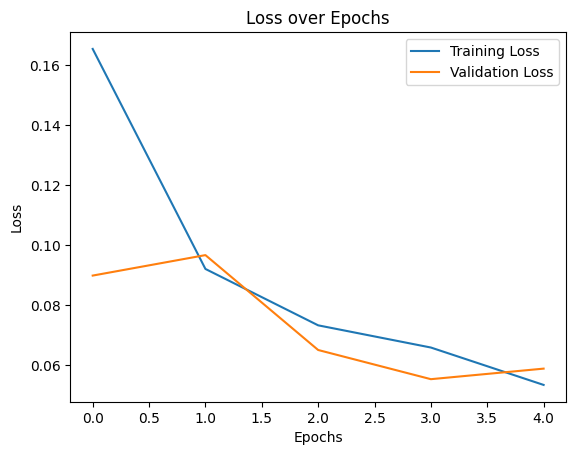

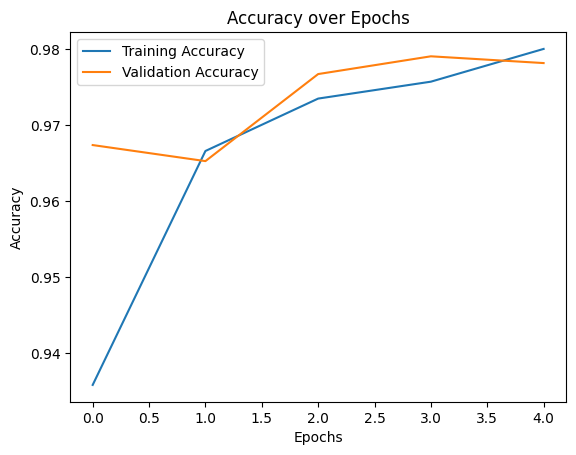

In [20]:
import matplotlib.pyplot as plt
# Vẽ biểu đồ Loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Vẽ biểu đồ Accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()